In [1]:
# For handling data (like a spreadsheet)
import pandas as pd

# For math and calculations
import numpy as np

# For plotting (histograms, boxplots, etc.)
import matplotlib.pyplot as plt
import seaborn as sns

# For statistics (t-tests, Q-Q plots)
import scipy.stats as stats
import statsmodels.api as sm

# For machine learning (the regression model)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Set a nice style for plots
sns.set(style="whitegrid")

In [2]:
# The filename must match EXACTLY what you uploaded
file_name = "Set 8 - Movie recommendation.csv"
df = pd.read_csv(file_name)

# Let's do our first inspection (Unit 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     2000 non-null   int64  
 1   movieId    2000 non-null   int64  
 2   rating     1883 non-null   float64
 3   timestamp  1900 non-null   float64
 4   title      2000 non-null   object 
 5   genres     1900 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 93.9+ KB


In [3]:
# A quick "sniff test"
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247.0,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224.0,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,NaN,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [4]:
# Create a new, clean DataFrame
df_cleaned = df.copy()

# 1 & 2: Drop rows where 'rating' or 'timestamp' are missing
# We use .dropna() on a subset of columns
original_rows = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=['rating', 'timestamp'])
rows_after_drop = len(df_cleaned)

# 3. Fill missing 'genres' with a placeholder
df_cleaned['genres'] = df_cleaned['genres'].fillna('Uncategorized')

# --- Summary of Cleaning ---
print(f"Original rows: {original_rows}")
print(f"Rows after dropping missing ratings/timestamps: {rows_after_drop}")
print(f"Total rows dropped: {original_rows - rows_after_drop}")
print("\nMissing values remaining in 'genres':")
print(df_cleaned['genres'].isnull().sum())
print("\nCleaned data info:")
df_cleaned.info()

Original rows: 2000
Rows after dropping missing ratings/timestamps: 1787
Total rows dropped: 213

Missing values remaining in 'genres':
0

Cleaned data info:
<class 'pandas.core.frame.DataFrame'>
Index: 1787 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     1787 non-null   int64  
 1   movieId    1787 non-null   int64  
 2   rating     1787 non-null   float64
 3   timestamp  1787 non-null   float64
 4   title      1787 non-null   object 
 5   genres     1787 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 97.7+ KB


In [5]:
# --- 1. Rating Statistics ---
print("--- Rating Statistics ---")
# .describe() gives most of what we need
rating_stats = df_cleaned['rating'].describe()
print(rating_stats)

# Get the mode (most frequent value)
rating_mode = df_cleaned['rating'].mode()[0]
print(f"Mode: {rating_mode}")

# Get the range (max - min)
rating_range = df_cleaned['rating'].max() - df_cleaned['rating'].min()
print(f"Range: {rating_range}")


# --- 2. User Frequency Statistics ---
print("\n--- User Frequency Statistics (Ratings per User) ---")
# First, we have to calculate the frequency for each user
user_freq = df_cleaned['userId'].value_counts()

# Now, we can describe that new list of numbers
user_freq_stats = user_freq.describe()
print(user_freq_stats)

# Get the mode
user_freq_mode = user_freq.mode()[0]
print(f"Mode: {user_freq_mode}")

# Get the range
user_freq_range = user_freq.max() - user_freq.min()
print(f"Range: {user_freq_range}")

--- Rating Statistics ---
count    1787.000000
mean        3.654729
std         1.069915
min         0.500000
25%         3.000000
50%         4.000000
75%         4.500000
max         5.000000
Name: rating, dtype: float64
Mode: 4.0
Range: 4.5

--- User Frequency Statistics (Ratings per User) ---
count     18.000000
mean      99.277778
std       77.306727
min       26.000000
25%       37.000000
50%       72.000000
75%      134.000000
max      282.000000
Name: count, dtype: float64
Mode: 44
Range: 256


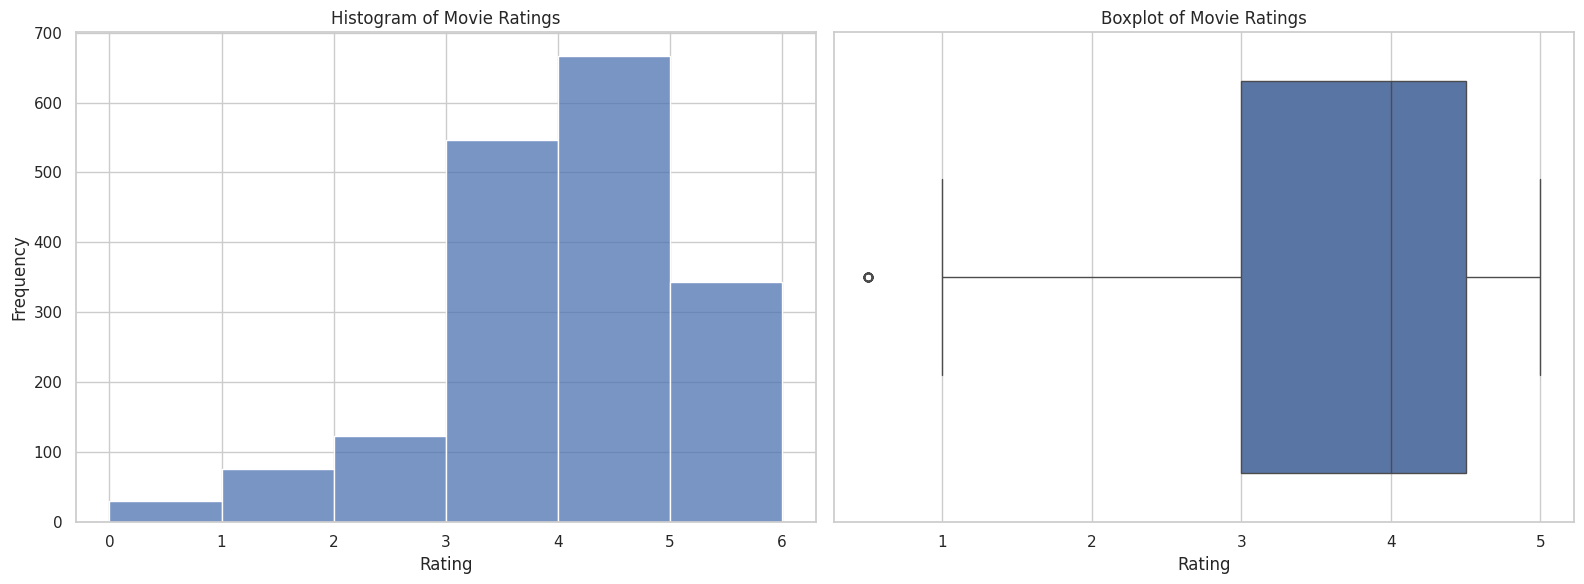

In [6]:
# Create a figure with two subplots, side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. Histogram ---
sns.histplot(df_cleaned['rating'], bins=9, kde=False, ax=axes[0], discrete=True)
axes[0].set_title('Histogram of Movie Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')

# --- 2. Boxplot ---
sns.boxplot(x=df_cleaned['rating'], ax=axes[1])
axes[1].set_title('Boxplot of Movie Ratings')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

Q1: 3.0
Q3: 4.5
IQR: 1.5
Lower Bound (Q1 - 1.5*IQR): 0.75
Upper Bound (Q3 + 1.5*IQR): 6.75

Original cleaned rows: 1787
Rows after outlier removal: 1756
Outliers removed: 31


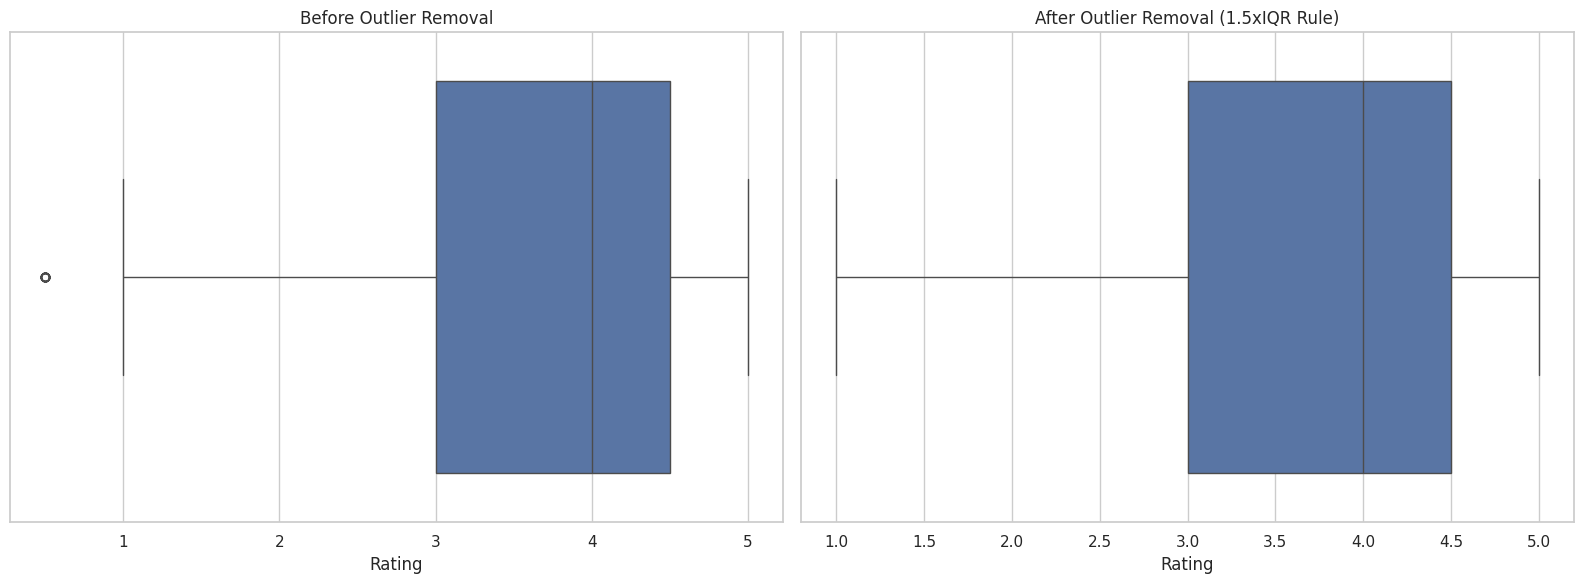

In [7]:
# --- 1. Calculate IQR and Bounds ---
Q1 = df_cleaned['rating'].quantile(0.25)
Q3 = df_cleaned['rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound (Q1 - 1.5*IQR): {lower_bound}")
print(f"Upper Bound (Q3 + 1.5*IQR): {upper_bound}")

# --- 2. Create new DataFrame without outliers ---
# We keep only the rows where the rating is WITHIN the bounds
df_no_outliers = df_cleaned[(df_cleaned['rating'] >= lower_bound) &
                            (df_cleaned['rating'] <= upper_bound)]

print(f"\nOriginal cleaned rows: {len(df_cleaned)}")
print(f"Rows after outlier removal: {len(df_no_outliers)}")
print(f"Outliers removed: {len(df_cleaned) - len(df_no_outliers)}")

# --- 3. Plot Before and After ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Before
sns.boxplot(x=df_cleaned['rating'], ax=axes[0])
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Rating')

# After
sns.boxplot(x=df_no_outliers['rating'], ax=axes[1])
axes[1].set_title('After Outlier Removal (1.5xIQR Rule)')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

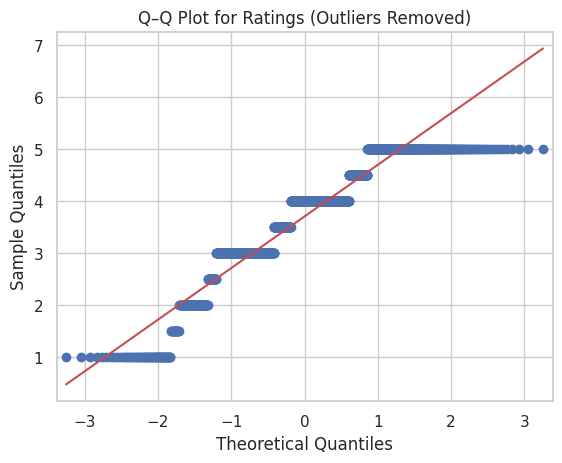

In [8]:
# We use statsmodels (sm) for this
sm.qqplot(df_no_outliers['rating'], line='s')
plt.title('Q–Q Plot for Ratings (Outliers Removed)')
plt.show()

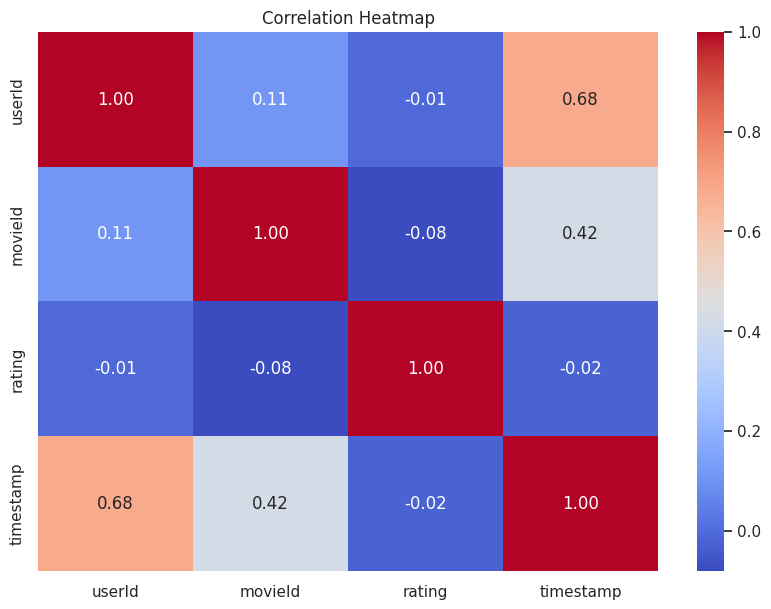

In [9]:
# We want to see how the numerical variables relate
# We will use the main df_cleaned DataFrame for this
numerical_cols = ['userId', 'movieId', 'rating', 'timestamp']
corr_matrix = df_cleaned[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Generating pairplot... This may take a moment.


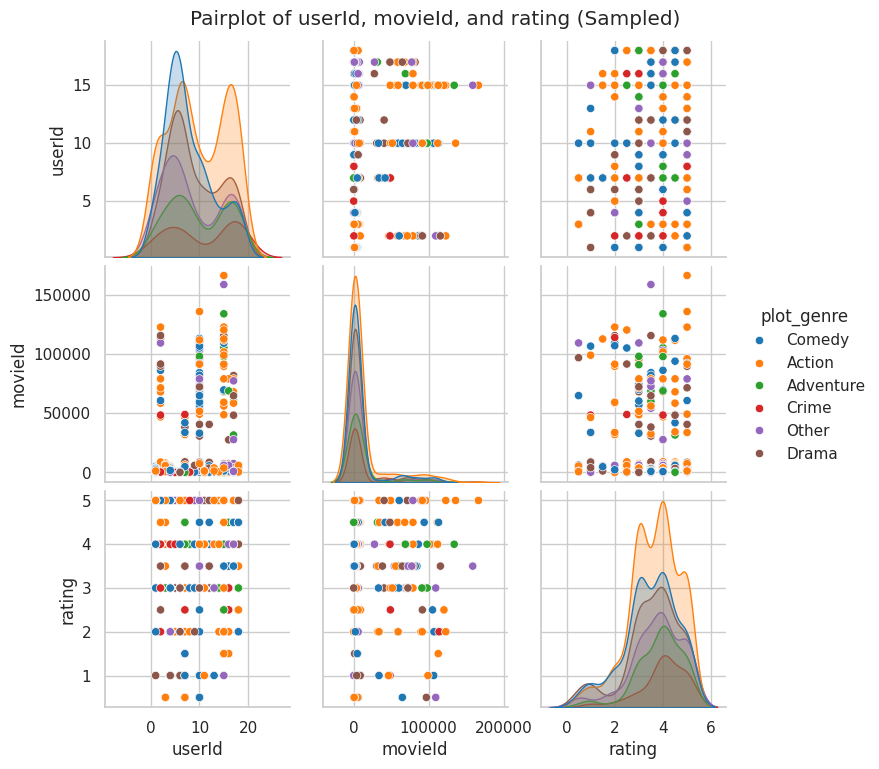

In [10]:
# --- 1. Prepare data for the plot ---
# Create a 'primary_genre' column to use for color
df_cleaned['primary_genre'] = df_cleaned['genres'].apply(lambda x: x.split('|')[0])

# Get the top 5 genres for cleaner coloring
top_genres = df_cleaned['primary_genre'].value_counts().nlargest(5).index.tolist()

# Make a new column that only has top genres, and lumps the rest into 'Other'
df_cleaned['plot_genre'] = df_cleaned['primary_genre'].apply(lambda g: g if g in top_genres else 'Other')

# --- 2. Take a small, random sample ---
# Taking 1000 data points (out of 110,000+) so the plot is fast
df_sample = df_cleaned.sample(n=1000, random_state=42)

# --- 3. Create the pairplot ---
print("Generating pairplot... This may take a moment.")
sns.pairplot(df_sample, vars=['userId', 'movieId', 'rating'], hue='plot_genre', palette='tab10')
plt.suptitle('Pairplot of userId, movieId, and rating (Sampled)', y=1.02)
plt.show()

In [11]:
# We will use df_cleaned for this unit
# The 'genres' column (e.g., "Action|Adventure|Sci-Fi") needs to be split
# .assign() creates a new 'genre' column by splitting the 'genres' string
# .explode() then takes each item in the split list and creates a new row for it

print("Exploding 'genres' column... This may take a moment.")
df_exploded = df_cleaned.assign(genre=df_cleaned['genres'].str.split('|')).explode('genre')

# Let's clean up any extra spaces
df_exploded['genre'] = df_exploded['genre'].str.strip()

print("Original cleaned rows:", len(df_cleaned))
print("New 'exploded' rows:", len(df_exploded))
print("\nExample of the new 'exploded' data:")
print(df_exploded[['title', 'genres', 'genre']].head())

Exploding 'genres' column... This may take a moment.
Original cleaned rows: 1787
New 'exploded' rows: 4732

Example of the new 'exploded' data:
              title                                       genres      genre
0  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy  Adventure
0  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy  Animation
0  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   Children
0  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy     Comedy
0  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy    Fantasy


Total 'Action' ratings: 511
Total 'Drama' ratings: 761

Levene's Test p-value: 0.660690712758768

--- T-Test Results ---
Action Mean Rating: 3.6429
Drama Mean Rating: 3.6511
T-statistic: -0.1345
P-value: 0.8930443180238465


/tmp/ipython-input-3134428015.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Action', 'Drama'],


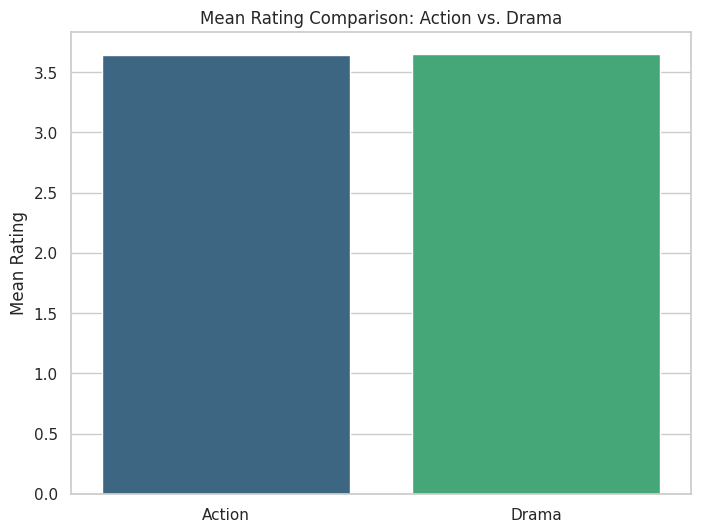

In [12]:
# --- 1. State Hypotheses (for our report) ---
# H0 (Null Hypothesis): The mean rating of 'Action' movies is equal to the mean rating of 'Drama' movies.
# Ha (Alternative Hypothesis): The mean rating of 'Action' movies is NOT equal to 'Drama' movies.

# --- 2. Get the data for each genre ---
ratings_action = df_exploded[df_exploded['genre'] == 'Action']['rating']
ratings_drama = df_exploded[df_exploded['genre'] == 'Drama']['rating']

print(f"Total 'Action' ratings: {len(ratings_action)}")
print(f"Total 'Drama' ratings: {len(ratings_drama)}")

# --- 3. Check for equal variances (Levene's Test) ---
# H0 for Levene's: The variances are equal.
levene_test = stats.levene(ratings_action, ratings_drama)
print(f"\nLevene's Test p-value: {levene_test.pvalue}")

# If p-value < 0.05, variances are NOT equal, and we must use Welch's T-test
equal_var_flag = levene_test.pvalue > 0.05
if not equal_var_flag:
    print("Variances are not equal. Using Welch's T-test.")

# --- 4. Perform the T-test ---
# The ttest_ind function can run Welch's test if we set equal_var=False
ttest_result = stats.ttest_ind(ratings_action, ratings_drama, equal_var=equal_var_flag)

print("\n--- T-Test Results ---")
print(f"Action Mean Rating: {ratings_action.mean():.4f}")
print(f"Drama Mean Rating: {ratings_drama.mean():.4f}")
print(f"T-statistic: {ttest_result.statistic:.4f}")
print(f"P-value: {ttest_result.pvalue}")

# --- 5. Visualize the means ---
plt.figure(figsize=(8, 6))
sns.barplot(x=['Action', 'Drama'],
            y=[ratings_action.mean(), ratings_drama.mean()],
            palette="viridis")
plt.title('Mean Rating Comparison: Action vs. Drama')
plt.ylabel('Mean Rating')
plt.show()

In [13]:
# We can re-use the 'ratings_drama' Series from the previous cell
n = len(ratings_drama)
mean = ratings_drama.mean()

# Calculate Standard Error of the Mean (SEM)
std_err = stats.sem(ratings_drama)

# Get the t-critical value for 95% confidence (0.975 for two-tailed)
# ppf is the Percent Point Function (inverse of CDF)
t_crit = stats.t.ppf(0.975, df=n-1)

# Calculate Margin of Error (ME)
margin_of_error = std_err * t_crit

print(f"--- Margin of Error for 'Drama' @ 95% CI ---")
print(f"Sample Size (n): {n}")
print(f"Mean Rating: {mean:.4f}")
print(f"Standard Error (SEM): {std_err:.4f}")
print(f"T-critical value: {t_crit:.4f}")
print(f"Margin of Error (ME): +/- {margin_of_error:.4f}")
print(f"\n95% Confidence Interval: [{mean - margin_of_error:.4f}, {mean + margin_of_error:.4f}]")

--- Margin of Error for 'Drama' @ 95% CI ---
Sample Size (n): 761
Mean Rating: 3.6511
Standard Error (SEM): 0.0394
T-critical value: 1.9631
Margin of Error (ME): +/- 0.0774

95% Confidence Interval: [3.5738, 3.7285]


In [14]:
# --- 1. Define Predictors (X) and Target (y) ---
# We use the main df_cleaned DataFrame
predictors = ['movieId', 'userId', 'timestamp']
target = 'rating'

X = df_cleaned[predictors]
y = df_cleaned[target]

# --- 2. Split data into training and testing sets ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# --- 3. Initialize and Fit the Model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- 4. Make predictions on the test set ---
y_pred = model.predict(X_test)

# --- 5. Evaluate Model Performance ---
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print("\n--- Regression Model Performance ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Training samples: 1429
Testing samples: 358

--- Regression Model Performance ---
R-squared (R²): -0.0140
Mean Absolute Error (MAE): 0.8427
Root Mean Squared Error (RMSE): 1.0981


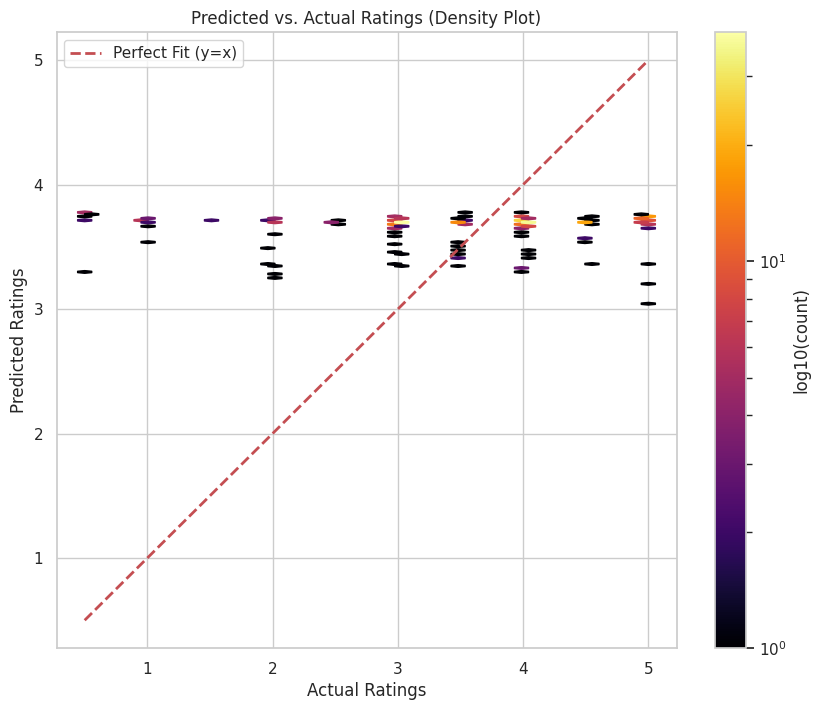

In [15]:
# A standard scatter plot of 22,000+ points will be a solid blob.
# A hexbin plot is much better, as it shows density.

plt.figure(figsize=(10, 8))
# bins='log' is used because some spots will have 1000s of points and others only 1
plt.hexbin(y_test, y_pred, gridsize=40, cmap='inferno', bins='log')

# Plot the "perfect fit" line (where y_pred == y_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Fit (y=x)')

plt.colorbar(label='log10(count)')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Predicted vs. Actual Ratings (Density Plot)')
plt.legend()
plt.show()

In [16]:
# --- 1. State Hypotheses ---
# H0: The mean difference between actual and predicted ratings is 0.
# Ha: The mean difference is NOT 0.

# --- 2. Perform a Paired T-Test ---
# We use a paired test (ttest_rel) because each prediction
# corresponds directly to one actual rating.
paired_ttest = stats.ttest_rel(y_test, y_pred)

print("--- Paired T-Test: Actual vs. Predicted Means ---")
print(f"Actual Mean: {y_test.mean():.4f}")
print(f"Predicted Mean: {y_pred.mean():.4f}")
print(f"T-statistic: {paired_ttest.statistic:.4f}")
print(f"P-value: {paired_ttest.pvalue}")

--- Paired T-Test: Actual vs. Predicted Means ---
Actual Mean: 3.5656
Predicted Mean: 3.6765
T-statistic: -1.9178
P-value: 0.05593671779094485


In [17]:
df.describe()

,userId,movieId,rating,timestamp
count,2000.000000,2000.00000,1883.000000,1.900000e+03
mean,9.137000,10391.14100,3.648964,1.132077e+09
std,5.678147,26083.75472,1.077241,2.502722e+08
min,1.000000,1.00000,0.500000,8.354410e+08
25%,4.000000,480.00000,3.000000,9.021547e+08
50%,7.000000,1352.00000,4.000000,1.044657e+09
75%,15.000000,3884.75000,4.500000,1.445715e+09
max,18.000000,166635.00000,5.000000,1.517686e+09
